<a href="https://colab.research.google.com/github/Leo05-u/EMSC2010_A3-Project-Notebook-Repository/blob/main/EMSC2010_A3_Project_Notebook_%26_Repository_u7447903.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**A3:** Project Notebook & Repository

**Student:** Leo Moore (u7447903)


**Scope:**  

The scope of the project is limited to analysing the Australian population data from 2015 to 2025, with particular focus on birth rates, death rates, and migration patterns, as these are the primary factors influencing population change. The scope was limited to Australia as over the past decade, many developed countries have experienced changes in fertility rates and ageing populations which can influence population growth. Understanding these trends is important because population size affects the economy, workforce, healthcare systems, housing demand, and government planning.  
<br><br>
**Introduction:**

This notebook focuses on determining whether Australia is experiencing declining population growth and whether this trend is likely to continue in the foreseeable future. Australia’s population is constantly changing due to factors such as birth rates, death rates, and migration. Birth and death rates are essential indicators for understanding how populations grow or decline over time. For the purposes of this investigation, population refers to the number of individuals living within a country. The country of interest is Australia.

This notebook uses statistical modelling techniques, including polynomial regression and bootstrapping, to analyse trends and evaluate possible future outcomes. While external factors such as economic conditions, government policy, and global events may influence future population changes, these factors are outside the scope of this project.

This notebook will evaluate changes in Australia’s population over time. Migration will be concidered as a positive flux into the population as a way of further understanding the population model.
<br><br>
**Aim:**

To analyse trends in Australia’s population change over the past decade and evaluate whether these trends are likely to persist in the foreseeable future.

**Dataset selection & cleaning**

Original data source:

 https://anu365-my.sharepoint.com/:x:/g/personal/u7447903_anu_edu_au/IQByZJS4Cp7JS5tvc3dwtmM7AbzltfYk_iXXTVLNupq2W1c?e=Fuwv62

Clean data used for the calculations within this notebook:

 https://anu365-my.sharepoint.com/:x:/g/personal/u7447903_anu_edu_au/IQBHRjtq0kTeQIHrPhKs4CuhAe9TkeEBmuRkty7g4z5emvY?e=5LvksX


In [ ]:
#IMPORTING THE LIBRARIES
import pandas as pd #for data importing
import numpy as np #for numerical operations
import matplotlib.pyplot as plt #for plotting

#Note to self: delete any imports that don't get utilised

In [ ]:
# Load the cleaned coral cover dataset from the Excel file

spreadsheet_name = 'Monthly_B&DRates_ByYear.xlsx'
worksheet_name = 'Sheet1'

df = pd.read_excel(spreadsheet_name, sheet_name=worksheet_name)

In [ ]:
#showing the dataframe
df.head()

,Year,Month,Births,Deaths
0,2015,January,6001,4698
1,2015,February,7441,3926
2,2015,March,8612,3718
3,2015,April,8079,3846
4,2015,May,12551,4757


In [ ]:
#Averaging the yearly birth and death rates

average_yearly_births = df.groupby('Year')['Births'].mean()
display(average_yearly_births)

average_yearly_deaths = df.groupby('Year')['Deaths'].mean()
display(average_yearly_deaths)

,Births
Year,
2015,8242.666667
2016,7901.166667
2017,7735.416667
2018,9028.583333
2019,8127.250000
2020,7852.416667
2021,8330.833333
2022,8028.333333
2023,7551.000000


,Deaths
Year,
2015,4420.500000
2016,4437.083333
2017,4348.583333
2018,4434.916667
2019,4637.000000
2020,4338.000000
2021,4661.916667
2022,5191.583333
2023,4905.833333


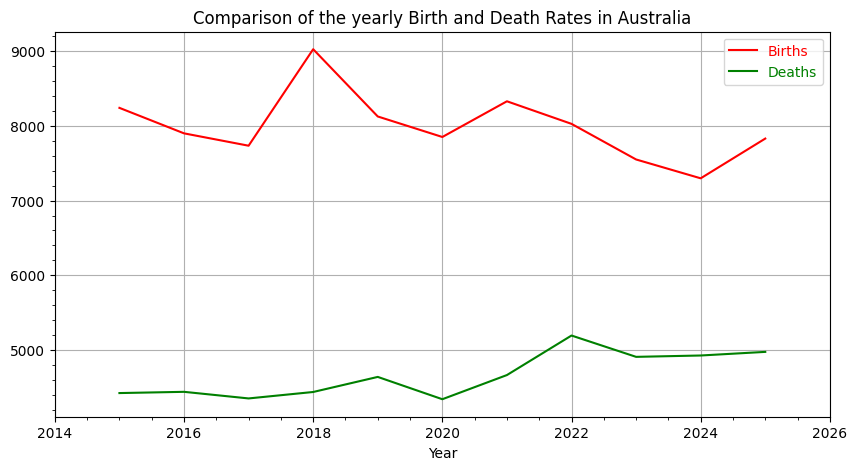

In [ ]:
#Generating the rough plot for the yearly birth and death rates

fig, ax = plt.subplots(figsize=(10, 5)) #size of plot
ax.plot(average_yearly_births.index, average_yearly_births,'r') #Births per year
ax.plot(average_yearly_deaths.index, average_yearly_deaths,'g') #Deaths per year
ax.set_xlabel('Year') #text for the x-axis label
ax.set_title('Comparison of the yearly Birth and Death Rates in Australia') #text for the title
legend = ax.legend(['Births','Deaths'], labelcolor='linecolor') #text for the legend
ax.grid() #show the gridlines
ax.set_xlim([2014,2026]) #interval for the x-axis
ax.minorticks_on() #show the minor ticks

This graph shows the birth and death dates by year as a quick visualisation of the collected data. It was used to formulate assumptions before any analysis of the data.

**Begining of polynomial regression**

In [ ]:
!pip install bambi # Install bambi
import bambi as bmb # Use bambi, aliased as bmb
import arviz as az #for analysis of Bayesian models

data_B = pd.DataFrame({"x": df['Year'], "y": df['Births']}) #put the data into a dataframe with variable names "x" and "y".
model_B = bmb.Model("y ~ x", data_B) #setup the first-order polynomial model
idata_B = model_B.fit(draws=2000, tune=2000, chains=8, progressbar=False) #sample the posteriors

data_D = pd.DataFrame({"a": df['Year'], "b": df['Deaths']}) #put the data into a dataframe with variable names "a" and "b".
model_D = bmb.Model("b ~ a", data_D) #setup the first-order polynomial model
idata_D = model_D.fit(draws=2000, tune=2000, chains=8, progressbar=False) #sample the posteriors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.8/237.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.9/179.9 kB 14.3 MB/s eta 0:00:00
  Attempting uninstall: pytensor
    Found existing installation: pytensor 2.38.2
    Uninstalling pytensor-2.38.2:
      Successfully uninstalled pytensor-2.38.2
  Attempting uninstall: arviz
    Found existing installation: arviz 0.22.0
    Uninstalling arviz-0.22.0:
      Successfully uninstalled arviz-0.22.0
  Attempting uninstall: pymc
    Found existing ins

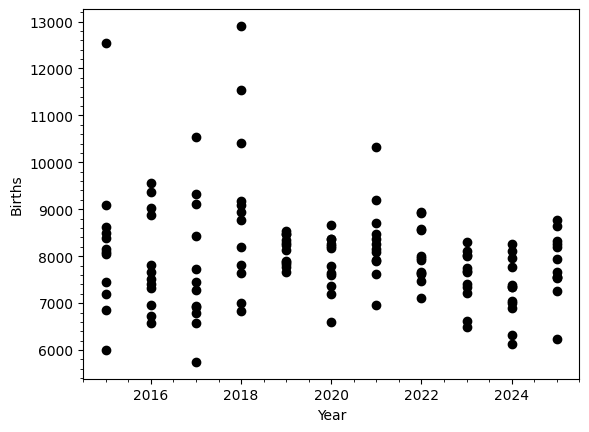

In [ ]:
# Initial plot of birth rates over years
plt.plot(df['Year'], df['Births'],'ok')
plt.xlabel('Year')
plt.ylabel('Births')
plt.minorticks_on()

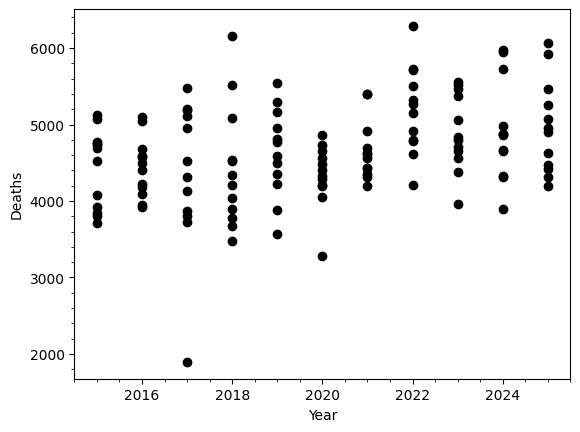

In [ ]:
# Initial plot of death rates over years
plt.plot(df['Year'], df['Deaths'],'ok')
plt.xlabel('Year')
plt.ylabel('Deaths')
plt.minorticks_on()

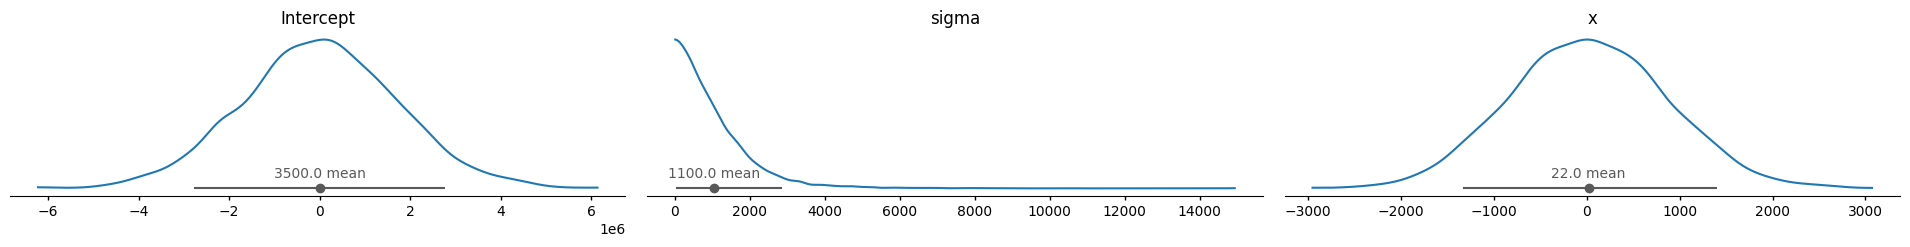

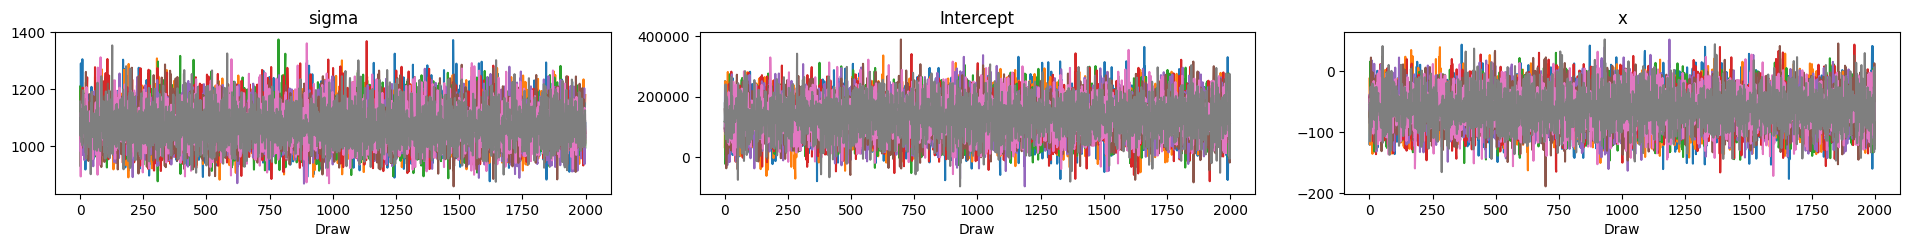

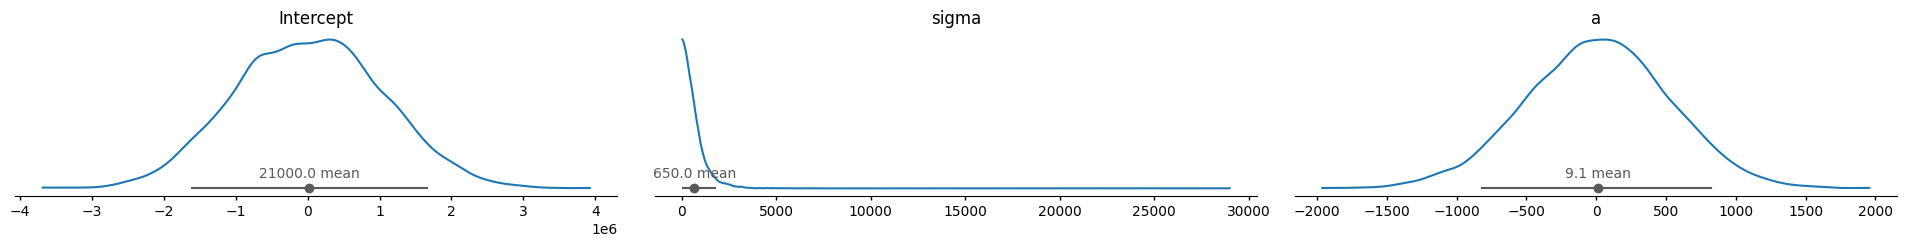

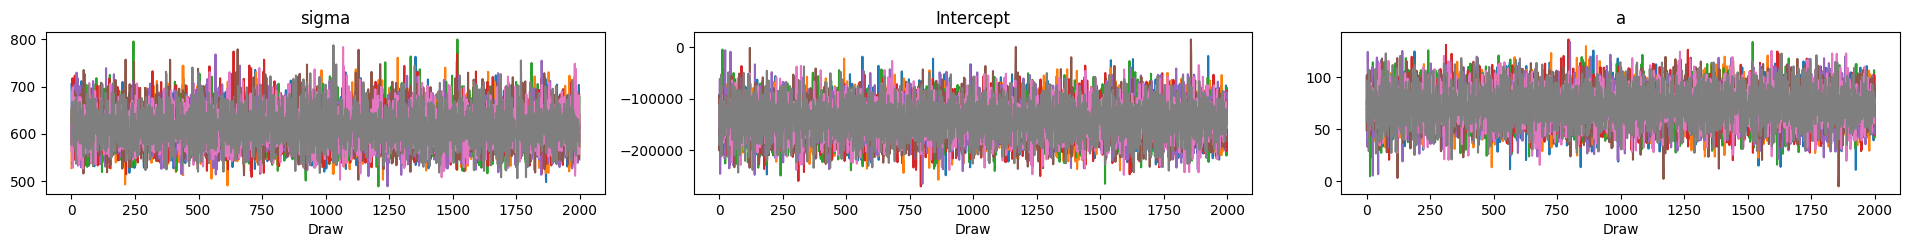

In [ ]:
# Modelling the priors for the birth and death rates
model_B.plot_priors()
plt.tight_layout()
plt.show()
az.plot_trace(idata_B);
plt.tight_layout() #this spaces the plots out so that they don't overlap

model_D.plot_priors()
plt.tight_layout()
plt.show()
az.plot_trace(idata_D);
plt.tight_layout() #this spaces the plots out so that they don't overlap

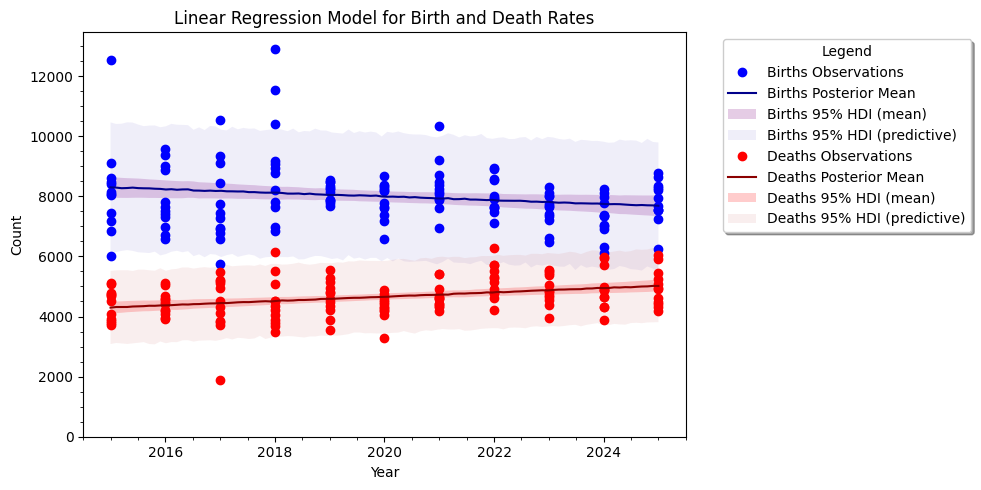

In [ ]:
from matplotlib.ticker import MaxNLocator

# Define prediction range from the min to max year in the dataset
min_year = int(df['Year'].min())
max_year = int(df['Year'].max())
x_range_years = np.linspace(min_year, max_year, 100)

# Create new dataframes for prediction for births and deaths
new_data_births = pd.DataFrame({"x": x_range_years})
new_data_deaths = pd.DataFrame({"a": x_range_years})

# Predict the distribution of regression lines for births
idata_predictions_births_params = model_B.predict(idata_B, data=new_data_births, kind='response_params', inplace=False)
idata_predictions_births_response = model_B.predict(idata_B, data=new_data_births, kind='response', inplace=False)

# Make random draws from the posterior for births
y_births_mean_draws = idata_predictions_births_params.posterior["mu"].values.reshape(-1, len(x_range_years))
y_births_pps_draws = idata_predictions_births_response.posterior_predictive["y"].values.reshape(-1, len(x_range_years))

# Compute the mean and HDI of the posterior predictive distribution for births
posterior_mean_births = y_births_pps_draws.mean(axis=0)
hdi_mean_births = az.hdi(y_births_mean_draws, 0.95, axis=0)
hdi_pps_births = az.hdi(y_births_pps_draws, 0.95, axis=0)

# Predict the distribution of regression lines for deaths
idata_predictions_deaths_params = model_D.predict(idata_D, data=new_data_deaths, kind='response_params', inplace=False)
idata_predictions_deaths_response = model_D.predict(idata_D, data=new_data_deaths, kind='response', inplace=False)

# Make random draws from the posterior for deaths
y_deaths_mean_draws = idata_predictions_deaths_params.posterior["mu"].values.reshape(-1, len(x_range_years))
y_deaths_pps_draws = idata_predictions_deaths_response.posterior_predictive["b"].values.reshape(-1, len(x_range_years))

# Compute the mean and HDI of the posterior predictive distribution for deaths
posterior_mean_deaths = y_deaths_pps_draws.mean(axis=0)
hdi_mean_deaths = az.hdi(y_deaths_mean_draws, 0.95, axis=0)
hdi_pps_deaths = az.hdi(y_deaths_pps_draws, 0.95, axis=0)

# PLOT BOTH POSTERIOR FOR REGRESSION LINES AND THE OBSERVATIONS
plt.figure(figsize=(10, 5))

# Births Plot
plt.plot(df['Year'], df['Births'], 'o', color='blue', label='Births Observations')
plt.plot(x_range_years, posterior_mean_births, color="darkblue", label='Births Posterior Mean')
plt.fill_between(
    x_range_years,
    hdi_mean_births[:, 0],
    hdi_mean_births[:, 1],
    alpha=0.2,
    color="purple",
    label='Births 95% HDI (mean)',
    edgecolor=None
)
plt.fill_between(
    x_range_years,
    hdi_pps_births[:, 0],
    hdi_pps_births[:, 1],
    alpha=0.1,
    color="slateblue",
    label='Births 95% HDI (predictive)',
    edgecolor=None
)

# Deaths Plot
plt.plot(df['Year'], df['Deaths'], 'o', color='red', label='Deaths Observations')
plt.plot(x_range_years, posterior_mean_deaths, color="darkred", label='Deaths Posterior Mean')
plt.fill_between(
    x_range_years,
    hdi_mean_deaths[:, 0],
    hdi_mean_deaths[:, 1],
    alpha=0.2,
    color="red",
    label='Deaths 95% HDI (mean)',
    edgecolor=None
)
plt.fill_between(
    x_range_years,
    hdi_pps_deaths[:, 0],
    hdi_pps_deaths[:, 1],
    alpha=0.1,
    color="indianred",
    label='Deaths 95% HDI (predictive)',
    edgecolor=None
)

# LABELS & TITLES
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', shadow=True, title='Legend')
plt.minorticks_on()
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Linear Regression Model for Birth and Death Rates")
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# Restrict the y-axis to show only non-negative counts
ax = plt.gca()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

Polynomial regression of the birth and death rates between 2015 and 2025 is used to disply any trends in the data. Polynomial regression was used to show whether the long‑term trajectory of birth and death rates is bending upward or downward.

The polynomial modelling shows a downward trend in birth rates per year and an increasing trend in deaths per year. Despite the birth rate still being higher than the death rate, the trends of the data indicate that this may not always be the case. The expectation was that as birth rate increased, death rate would increase proportionally, however as seen above this is not the case. External factors are likely influencing the birth and death rates.

**Beginning of bootstrapping**

In [ ]:
BS_Births = np.random.choice(df['Births'], size=len(df['Births']), replace=True) #find the mean of the X array
print(np.mean(BS_Births))

BS_Deaths = np.random.choice(df['Deaths'], size=len(df['Deaths']), replace=True) #find the mean of the X array
print(np.mean(BS_Deaths))

8035.075757575758
4628.537878787879


In [ ]:
BS2_Births = np.random.choice(df['Births'], size=(len(df['Births']), 1000), replace=True) #Generate 1000 columns of Bootstraps
print(np.shape(BS2_Births))

BS2_Deaths = np.random.choice(df['Deaths'], size=(len(df['Deaths']), 1000), replace=True) #Generate 1000 columns of Bootstraps
print(np.shape(BS2_Deaths))

(132, 1000)
(132, 1000)


(1000,)
(1000,)


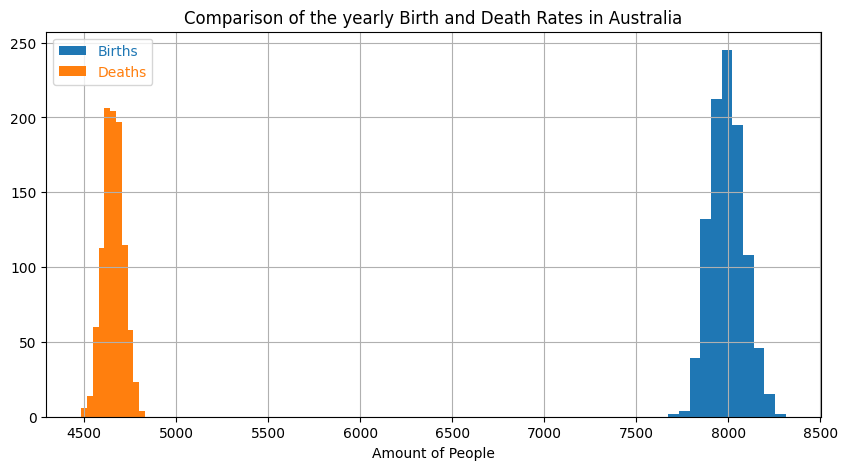

In [ ]:
bar_B = np.mean(BS2_Births, axis=0) #average of each column of the bootstrap for births
print(np.shape(bar_B))

bar_D = np.mean(BS2_Deaths, axis=0) #average of each column of the bootstrap for deaths
print(np.shape(bar_D))

# Creating a histogram for the bootstrap
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(bar_B, bins=11, label='Births') #11 used because its the amount of years of the dataset
ax.hist(bar_D, bins=11, label='Deaths') #11 used because its the amount of years of the dataset

ax.set_xlabel('Amount of People') #text for the x-axis label
ax.set_title('Comparison of the yearly Birth and Death Rates in Australia') #text for the title
ax.legend(labelcolor='linecolor') #text for the legend
ax.grid() #show the gridlines
plt.show()

In [ ]:
#Finding the confidence interval for the birth and death rates

CI_B = np.percentile(bar_B, [2.5, 97.5]) #95% confidence interval of births
print(CI_B)

CI_D = np.percentile(bar_D, [2.5, 97.5]) #95% confidence interval of deaths
print(CI_D)

[7830.28295455 8183.33087121]
[4554.1405303  4769.03049242]


Bootstrapping the data measures the amount of uncertainty exists in the birth and death rate data. This produces a distribution of possible outcomes where if most bootstrap samples show deaths exceeding births, it suggests natural decline and vice versa.

The bootstrap shows that birth rates are far exceeding death rates throught the random sampling. This indicates that it is highly likely that there are more births than deaths during any given year.

**Beginning of numerical modelling**

Numerical modelling of the birth and death rates allows me to address the limitations of the previous two models, such as migration into and out of Australia. Rather then relying on a single trend line, numerical models update the population on a year by year basis, showing how different factors interact dynamically. This allows for non‑linear patterns, testing of multiple scenarios, and highlights whether natural increase or decline is driving change.

For this notebook, migration will be the concidered factor Mt <br>
$P_{t+1} = P_t + B_t - D_t + M_t$

Where:

$P_t$ : population at time t <br>
$B_t$ : births during period t <br>
$D_t$ : deaths during period t <br>
$M_t$ : net migration during period t <br>

The Australian population will be rounded down to the nearest millionth for the year 2025. Births and deaths will be used from the 2025 average yearly data calculated at the top of this notebook rounded down to the nearest whole number. Migration will also be rounded down to the nearest thousandth for the 2025 financial year.

Data for population at time (t) was collected from the Australian Bureau of Statistics and can be found here:https://www.abs.gov.au/statistics/people/population/national-state-and-territory-population/latest-release

Data for migration at time (t) was collected from the Australian Bureau of Statistics and can be found here: https://www.abs.gov.au/statistics/people/population/overseas-migration/latest-release

According to their surveys, $P_t$ will be 27 million people and $M_t$ will begin at 306 thousand for the purposes of this notebook


In [ ]:
P_t = 27000000
B_t = 7831
D_t = 4972
M_t = 306000

In [ ]:
Delta_P = (P_t + B_t) - (D_t + M_t)
print(Delta_P)

26696859


In [ ]:
# Re-define initial scalar values to ensure consistency even if cells are run out of order
B_t_initial_scalar = 7831
M_t_initial_scalar = 306000
D_t_initial_scalar = 4972
P_t_initial_scalar = 27000000 # Capture initial P_t

years = max_year - min_year

# Capture these initial scalar values
B_t_0 = B_t_initial_scalar
M_t_0 = M_t_initial_scalar
D_t_0 = D_t_initial_scalar
P_t_0 = P_t_initial_scalar # Capture initial P_t for the series

time = np.arange(years + 1)

# Initialize arrays for time-series data
B_t = np.zeros(years + 1)
D_t = np.zeros(years + 1)
M_t = np.zeros(years + 1)
Delta_PnM = np.zeros(years + 1) # Array to store annual change in population no migration
Delta_PM = np.zeros(years + 1) # Array to store annual change in population with migration
P_seriesnM = np.zeros(years + 1) # Array to store total population over time no migration
P_seriesM = np.zeros(years + 1) # Array to store total population over time with migration

# Set initial values in the arrays
B_t[0] = B_t_0
M_t[0] = M_t_0
D_t[0] = D_t_0
P_seriesnM[0] = P_t_0 # Initial population no migration
P_seriesM[0] = P_t_0 # Initial population with migration

In [ ]:
# Define the annual change rates from regression slopes without migration
# dB_t represents the average annual change in births
dB_t = idata_B.posterior['x'].mean().item()

# dM_t represents the average annual change in net migration
dM_t = 0

# dD_t represents the average annual change in deaths
dD_t = idata_D.posterior['a'].mean().item()

# D_t[0] and P_series[0] are now initialized in cell F8WWUnYhGYW- with D_t_0 and P_t_0.

for i in range(years):

    # Update births using the calculated annual birth trend
    B_t[i+1] = B_t[i] + dB_t

    # Update deaths using the calculated annual death trend
    D_t[i+1] = D_t[i] + dD_t

    # Calculate the net change in population for the current year
    # This is (Births - Deaths + Migration) for the current period (i+1)
    Delta_PnM[i+1] = B_t[i+1] - D_t[i+1]

    # Update the total population for the current year
    P_seriesnM[i+1] = P_seriesnM[i] + Delta_PnM[i+1]

print("Annual Deaths (year 1):")
print(f"{D_t[1]:.2f} per year")

print("Annual Births (year 1):")
print(f"{B_t[1]:.2f} per year")

print("Annual Population Change (year 1): ")
print(f"{Delta_PnM[1]:.2f} per year")

print("\nProjected Total Population at end of period:")
print(f"{P_seriesnM[-1]:.0f}")

Annual Deaths (year 1):
5043.90 per year
Annual Births (year 1):
7769.40 per year
Annual Population Change (year 1): 
2725.50 per year

Projected Total Population at end of period:
27021248


In [ ]:
#Determining whether the population is increasing or decreasing based on annual change without the introduction of migration

# Check if there are any years where the population decreases (Delta_P is negative)
if (Delta_PnM[1:] < 0).any():

    first_decrease_relative_index = np.where(Delta_PnM[1:] < 0)[0][0]
    # Add 1 to get the absolute index in the original Delta_P array (since we sliced from [1:])
    first_decrease_absolute_index = first_decrease_relative_index + 1

    # The actual year would be min_year + absolute_index
    print(f"Population starts decreasing in year {min_year + first_decrease_absolute_index} (projected year index {first_decrease_absolute_index}).")
elif (Delta_PnM[1:] > 0).all():
    # If all annual changes (after year 0) are positive, the population is consistently increasing.
    print("Population is consistently increasing over the projected period.")
else:
    # This handles cases where there might be no clear increasing or decreasing trend, or if there are zero changes.
    print("Population trend is mixed or stable (not consistently increasing or decreasing).")

Population is consistently increasing over the projected period.


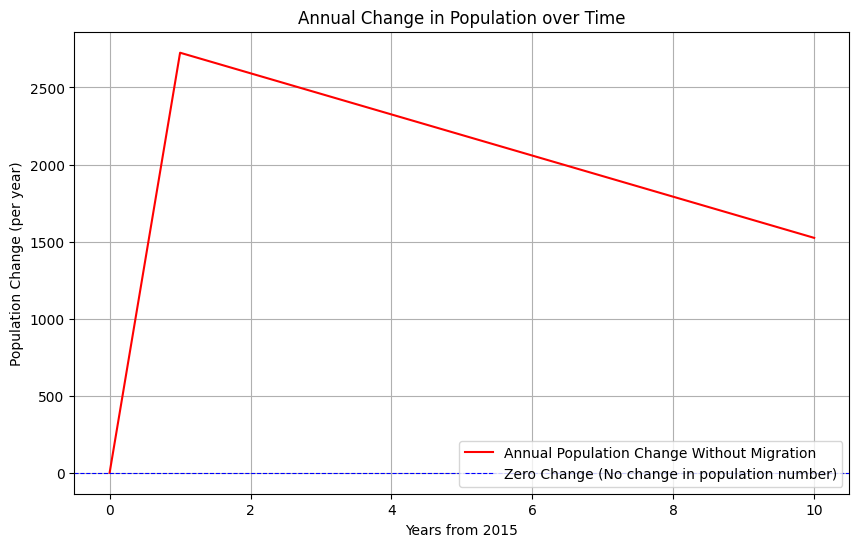

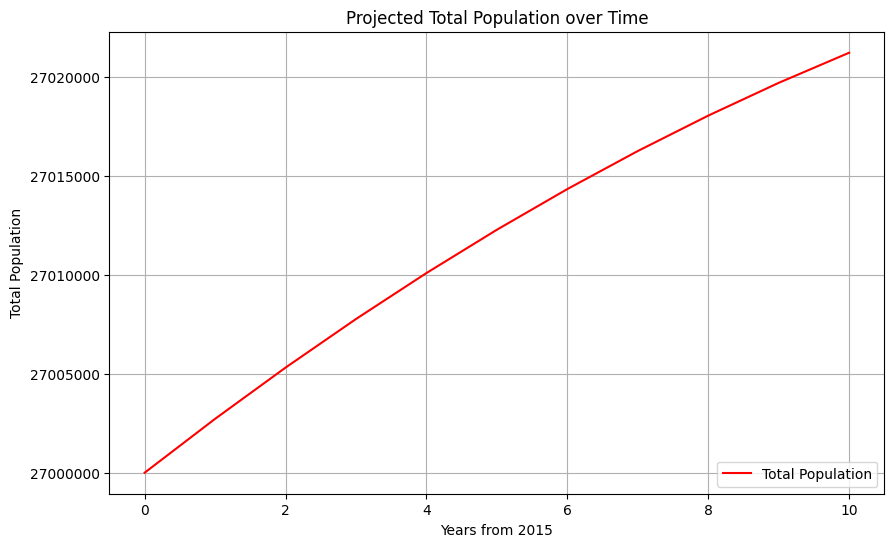

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(time, Delta_PnM, label='Annual Population Change Without Migration', color='red')

plt.xlabel('Years from ' + str(min_year))
plt.ylabel('Population Change (per year)')
plt.title('Annual Change in Population over Time')
plt.axhline(0, color='blue', linestyle='--', linewidth=0.8, label='Zero Change (No change in population number)')
plt.grid(True)
plt.legend(loc = 'lower right')

plt.show()

# Plot the total population over time
plt.figure(figsize=(10, 6))
plt.plot(time, P_seriesnM, label='Total Population', color='red')
plt.xlabel('Years from ' + str(min_year))
plt.ylabel('Total Population')
plt.title('Projected Total Population over Time')
plt.grid(True)
plt.legend(loc = 'lower right')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.show()

Without migration, the first graph demonstrates that the change in population remains above the zero-threshold line (horizontal line shown in the graph) during the simulation period showing the population doesn't decrease under the model assumptions. However, there is a clear decline illistrated suggesting the population is heading towards significant decrease should these trends continue. The second graph shows a slow linear relationship, showing an increasing trend regardless of the first graphs decrease.

In [ ]:
# Define the annual change rates from regression slopes with migration
# dB_t represents the average annual change in births
dB_t = idata_B.posterior['x'].mean().item()

# dM_t represents the average annual change in net migration
dM_t = 0

# dD_t represents the average annual change in deaths
dD_t = idata_D.posterior['a'].mean().item()

# D_t[0] and P_series[0] are now initialized in cell F8WWUnYhGYW- with D_t_0 and P_t_0.

for i in range(years):

    # Update births using the calculated annual birth trend
    B_t[i+1] = B_t[i] + dB_t

    # Update migration using the assumed annual migration trend (if added)
    M_t[i+1] = M_t[i] + dM_t

    # Update deaths using the calculated annual death trend
    D_t[i+1] = D_t[i] + dD_t

    # Calculate the net change in population for the current year
    # This is (Births - Deaths + Migration) for the current period (i+1)
    Delta_PM[i+1] = B_t[i+1] - D_t[i+1] + M_t[i+1]

    # Update the total population for the current year
    P_seriesM[i+1] = P_seriesM[i] + Delta_PM[i+1]

print("Annual Deaths (year 1):")
print(f"{D_t[1]:.2f} per year")

print("Annual Births (year 1):")
print(f"{B_t[1]:.2f} per year")

print("Annual Migration (year 1):")
print(f"{M_t[1]:.2f} per year")

print("Annual Population Change (year 1): ")
print(f"{Delta_PM[1]:.2f} per year")

print("\nProjected Total Population at end of period:")
print(f"{P_seriesM[-1]:.0f}")

Annual Deaths (year 1):
5043.90 per year
Annual Births (year 1):
7769.40 per year
Annual Migration (year 1):
306000.00 per year
Annual Population Change (year 1): 
308725.50 per year

Projected Total Population at end of period:
30081248


In [ ]:
#Determining whether the population is increasing or decreasing based on annual change with the introduction of migration

# Check if there are any years where the population decreases (Delta_P is negative)
if (Delta_PM[1:] < 0).any():

    first_decrease_relative_index = np.where(Delta_PM[1:] < 0)[0][0]
    # Add 1 to get the absolute index in the original Delta_P array (since we sliced from [1:])
    first_decrease_absolute_index = first_decrease_relative_index + 1

    # The actual year would be min_year + absolute_index
    print(f"Population starts decreasing in year {min_year + first_decrease_absolute_index} (projected year index {first_decrease_absolute_index}).")
elif (Delta_PM[1:] > 0).all():
    # If all annual changes (after year 0) are positive, the population is consistently increasing.
    print("Population is consistently increasing over the projected period.")
else:
    # This handles cases where there might be no clear increasing or decreasing trend, or if there are zero changes.
    print("Population trend is mixed or stable (not consistently increasing or decreasing).")

Population is consistently increasing over the projected period.


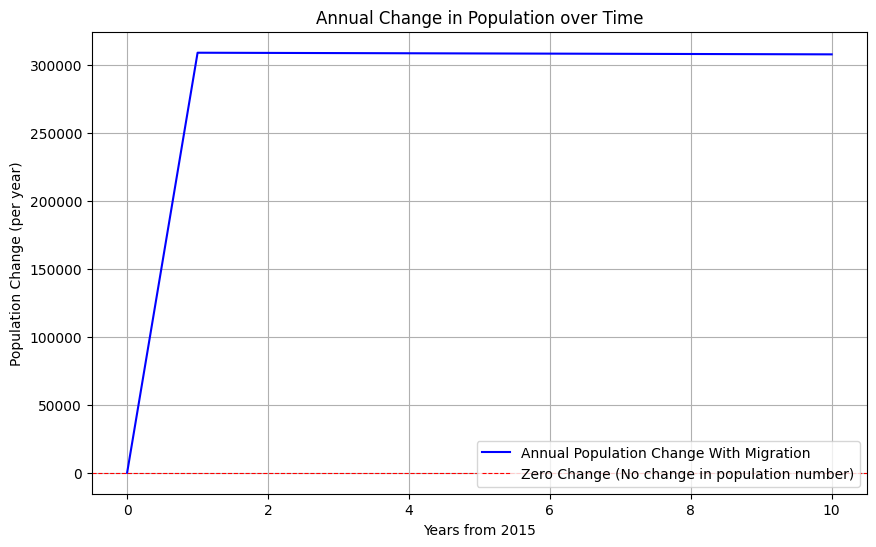

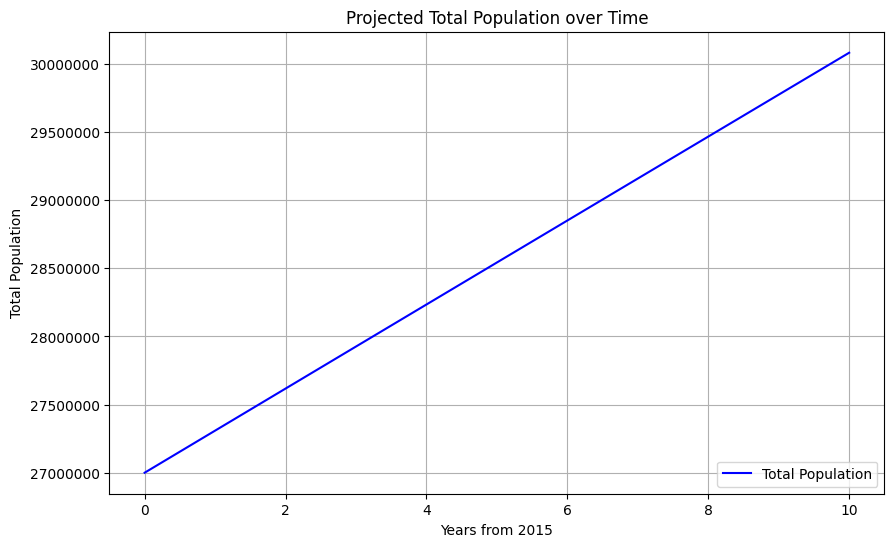

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(time, Delta_PM, label='Annual Population Change With Migration', color='blue')

plt.xlabel('Years from ' + str(min_year))
plt.ylabel('Population Change (per year)')
plt.title('Annual Change in Population over Time')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8, label='Zero Change (No change in population number)')
plt.grid(True)
plt.legend(loc = 'lower right')

plt.show()

# Plot the total population over time
plt.figure(figsize=(10, 6))
plt.plot(time, P_seriesM, label='Total Population', color='blue')
plt.xlabel('Years from ' + str(min_year))
plt.ylabel('Total Population')
plt.title('Projected Total Population over Time')
plt.grid(True)
plt.legend(loc = 'lower right')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.show()

With the introduction of migration into Austrralia, the population is shown to increase as expected. The first graph demonstrates that the change in population remains above the zero-threshold line (horizontal line shown in the graph) during the simulation period showing the population doesn't decrease under the model assumptions. However, the increase in population mostly doesn't influence the birth rate, only the death rate as the poeple entering Australia were already born for the most part. The second graph supports the first, showing a steady increase in population size in the years after 2015 up to 2025.

**Limitations:**

A limitation of the polynomial regression model is that it assumes historical population trends will continue unchanged into the future. The model may also overfit short-term fluctuations in the data, reducing the reliability of long-term population predictions.

Although bootstrapping provides estimates of variability and confidence within the data, it is limited by the quality and size of the original dataset. Any bias or inaccuracies that may have been in the original data are propagated throughout the resampling process.

The numerical model simplifies population change by focusing primarily on births and deaths. This reduces the complexity of real population systems and may limit the accuracy of future population projections, particularly because migration was shown to strongly influenced Australia’s population growth.

Overall, this notebook is limited by the assumption that current population trends will continue into the future. Population dynamics are influenced by unpredictable external factors, including migration policy, economic conditions, and global events, which cannot be accurately predicted using historical data alone.

**Conclusion:**

The polynomial regression analysis indicates a clear trend of decreasing birth rates and increasing death rates over time, suggesting a gradual decline in natural population growth in Australia. This trend is further supported by the numerical model when migration is not considered. Although birth rates currently remain higher than death rates, as demonstrated by the bootstrapped data analysis, the observed trends suggest that this may not remain the case in the future if current patterns continue.

However, external factors such as migration have a significant impact on Australia’s overall population growth. Current migration patterns contribute substantially to population increase, indicating that despite declining birth rates, Australia’s total population is still likely to experience net growth under current conditions for the foreseeable future.

**Reflection:**

The main reason I selected population decline as my topic was because population change is an important issue in the current political climate. I was particularly interested in whether Australia’s population growth is slowing due to declining birth rates and increasing death rates, as this is a trend that has been observed in many developed countries. I wanted to investigate whether similar population patterns could be identified in Australia using the moethods we've learnt in class.

Throughout the investigation, one of the main challenges I encountered was determining which modelling techniques were most appropriate for analysing population trends. Initially, I thought about using the Monte Carlo technique however after going back to previous notbooks and class notes I decided it wasn't an appropriate model and chose bootstrapping instead. As a result of my choice to do bootstrapping, I decided to use polynomial regression to better represent the changes in birth and death rates over time. However, the reliability of the model is questionable as I believe it may over fit the data.

Another challenge was accounting for the influence of external factors. Early in the project, I focused primarily on births and deaths when considering population change. However, after analysing the data further, it became clear that there had to be other large factors to concider since I was sure the population was increasing largely each year. This pushed me to research what the biggest influences of population growth are in other developed contries, one of the biggest being migration. Because of this, I decided to adjuste the scope of the investigation to include migration patterns to see how large the impact is. This significantly changed my conclusions, as the data showed that Australia’s population is still largely increasing overall despite declining natural population growth.

I struggled with the coding aspect of this report as well as it isn't an area I'm particularly familiar with. I had to use significant help from copilot and gemini to complete certain parts of the code which I had to then further look into to ensure the code was completing the task I intended. Despite the challenges of this, I believe it greatly increased my knowledge of copilot code and my understanding of the data that this notebook displays.
